In [ ]:
import utils
import nltk
import string

import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')

from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to /home/lenovo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/lenovo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/lenovo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
print(utils.paragraph_news)


In Minnesota, a flashpoint in Trump's crackdown on illegal immigration, a massive rally was held outside the state capitol in Saint Paul. Many held aloft posters bearing photos of Renee Good and Alex Pretti, U.S. citizens fatally shot by federal immigration officers in Minneapolis this year.
Minnesota Governor Tim Walz, the Democratic vice presidential nominee in 2024, told the crowd that their resistance to Trump and his policies makes them "the heart and soul" of everything good about the U.S.
"They cal us radicals," Walz said. "You're damn right we've been radicalized - radicalized by compassion, radicalized by decency, radicalized by due process, radicalized by democracy, and radicalized to do all we can to oppose authoritarianism."
U.S. Senator Bernie Sanders of Vermont, a Trump critic who sought the Democratic presidential nomination in 2016 and 2020, also addressed the event in Minnesota. Musician Bruce Springsteen performed his song "Streets of Minneapolis" - a ballad criticiz

In [ ]:
sentences_dirty = sent_tokenize(utils.paragraph_news)
sentences = []

translator = str.maketrans('', '', string.punctuation)
stop_words = stopwords.words("english")

for i in range(len(sentences_dirty)):
    current_sentence = sentences_dirty[i]
    current_sentence = current_sentence.lower()

    current_sentence = current_sentence.replace('\n\n', ' ').translate(translator)
    current_sentence = current_sentence.replace('\n', ' ').strip()

    sentence_cleaned = []
    sentence_tokens = word_tokenize(current_sentence)
    for token in sentence_tokens:
        if token not in stop_words:
            sentence_cleaned.append(token)

    current_sentence = " ".join(sentence_cleaned)

    sentences.append(current_sentence)

print(sentences)

['minnesota flashpoint trumps crackdown illegal immigration massive rally held outside state capitol saint paul', 'many held aloft posters bearing photos renee good alex pretti us citizens fatally shot federal immigration officers minneapolis year', 'minnesota governor tim walz democratic vice presidential nominee 2024 told crowd resistance trump policies makes heart soul everything good us cal us radicals walz said', 'youre damn right weve radicalized radicalized compassion radicalized decency radicalized due process radicalized democracy radicalized oppose authoritarianism', 'us', 'senator bernie sanders vermont trump critic sought democratic presidential nomination 2016 2020 also addressed event minnesota', 'musician bruce springsteen performed song streets minneapolis ballad criticizing trumps immigration crackdown lamenting deaths good pretti', 'allow country descend authoritarianism oligarchy america said sanders independent', 'people rule', 'national republican congressional com

In [ ]:
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sentences)

print(features.shape)

words = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(features.toarray(), columns=words)
tfidf_df

(23, 205)


,10,2016,2020,2024,54,acting,actor,addressed,alex,allow,...,vice,violent,walz,want,washington,weve,wheelchairs,year,york,youre
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.24232,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.24232,0.000000,0.00000
2,0.000000,0.000000,0.000000,0.202081,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.202081,0.000000,0.404162,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.14655,0.000000,0.00000,0.000000,0.14655
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
5,0.000000,0.264313,0.264313,0.000000,0.000000,0.000000,0.000000,0.264313,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.361183,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000


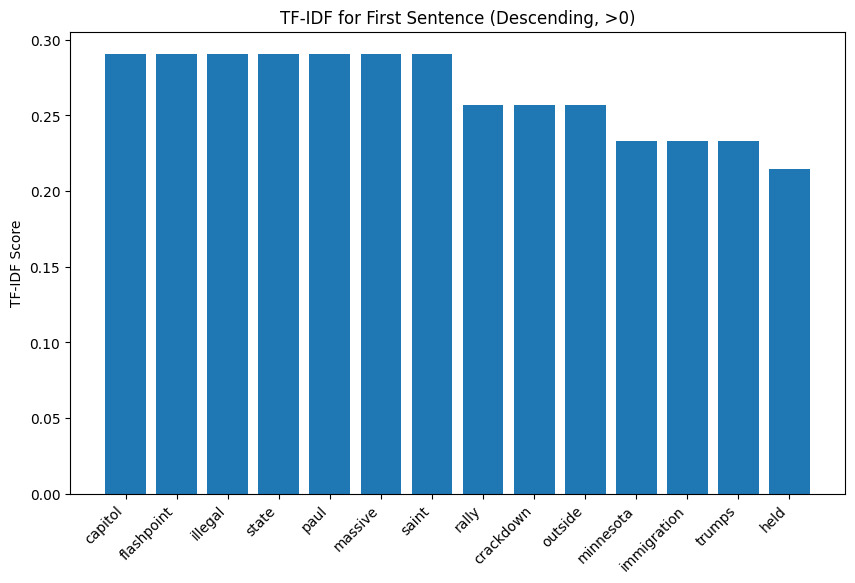

In [ ]:
first_sentence_tfidf = tfidf_df.iloc[0]

first_sentence_tfidf = first_sentence_tfidf[first_sentence_tfidf > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(first_sentence_tfidf.index, first_sentence_tfidf.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("TF-IDF Score")
plt.title("TF-IDF for First Sentence (Descending, >0)")
plt.show()

In [ ]:
averages = []

for index, data in tfidf_df.iterrows():
    row_average = 0
    if (data != 0).sum() > 0:
        row_average = data.sum() / (data != 0).sum()

        averages.append(row_average)

threshold = averages[0]

print(f"Minimum value: {threshold}")
for i in range(0, len(averages)):
    print(f"Sentence {i + 1} value: {averages[i]}")

final_result = ""
final_result_neat = ""

sentences_in_summary = []
for i in range(len(averages)):
    if (averages[i] >= threshold):
        final_result +=  " " + sentences_dirty[i]
        final_result_neat += " " + sentences_dirty[i] + "\n"
        sentences_in_summary.append(i)

print("\nSentences in summary:")
print(sentences_in_summary)

Minimum value: 0.26585372300553306
Sentence 1 value: 0.26585372300553306
Sentence 2 value: 0.22838901883438015
Sentence 3 value: 0.2005615919029647
Sentence 4 value: 0.20477061335313917
Sentence 5 value: 1.0
Sentence 6 value: 0.2486894968895746
Sentence 7 value: 0.24908784945598203
Sentence 8 value: 0.3298543490736745
Sentence 9 value: 0.705761731827018
Sentence 10 value: 0.3153439824984477
Sentence 11 value: 0.2225159892102072
Sentence 12 value: 0.28794950607076825
Sentence 13 value: 0.264633988671602
Sentence 14 value: 0.2652896972814924
Sentence 15 value: 0.4644547385771327
Sentence 16 value: 0.314641492541991
Sentence 17 value: 0.20764783046660118
Sentence 18 value: 0.40784976236612575
Sentence 19 value: 0.40758530394240716
Sentence 20 value: 0.329667606780805
Sentence 21 value: 0.31209765199777906
Sentence 22 value: 0.35355339059327373

Sentences in summary:
[0, 4, 7, 8, 9, 11, 14, 15, 17, 18, 19, 20, 21]


In [ ]:
print("Word counts:")
print(f"Original text: {len(utils.paragraph_news)}")
print(f"Summary: {len(final_result)}")

print("\nFinal summary: \n")
print(final_result)

Word counts:
Original text: 2775
Summary: 1114

Final summary: 


In Minnesota, a flashpoint in Trump's crackdown on illegal immigration, a massive rally was held outside the state capitol in Saint Paul.U.S."We will not allow this country to descend into authoritarianism or oligarchy in America," said Sanders, an independent."We, the people, will rule."The National Republican Congressional Committee criticized Democratic politicians and candidates for supporting the rallies.In New York, a crowd that police estimated at tens of thousands stretched more than 10 blocks in midtown Manhattan."We fought against having kings and we fought for freedom," she said."We're just doing it again."Outside a high-rise assisted-living center in Chevy Chase, Maryland, a group of elderly people in wheelchairs held signs encouraging passing cars to "Resist tyranny," "Honk if you want democracy" and "Dump Trump."Minor scuffles erupted when counterprotesters blocked streets.Dallas police eventually made seve